# (a) Create a Linearly Separable Dataset

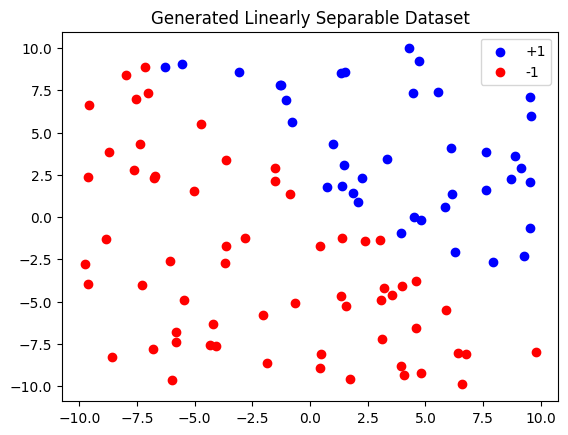

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

xs = -10
xe = 10
n = 100

# Generate random points
X = np.random.uniform(xs, xe, (n,2))

# Generate labels
y = np.where(X[:,0] + X[:,1] - 2 > 0, 1, -1)

# Plot data
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='+1')
plt.scatter(X[y==-1][:,0], X[y==-1][:,1], color='red', label='-1')

plt.legend()
plt.title("Generated Linearly Separable Dataset")
plt.show()

# (b) Hard-Margin SVM

In [2]:
from sklearn import svm

model = svm.SVC(kernel='linear', C=1e6)

model.fit(X, y)

w = model.coef_[0]
b = model.intercept_[0]

print("w =", w)
print("b =", b)

# margin width
margin = 2 / np.linalg.norm(w)

print("Margin width =", margin)

w = [2.7380427  2.74588987]
b = -5.8892720133915075
Margin width = 0.5157656827769558


# Plot the Decision Boundary

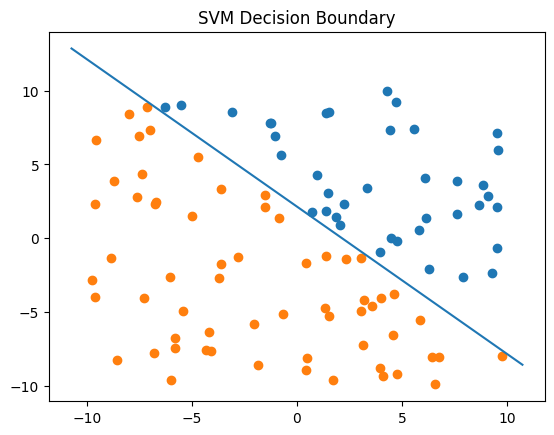

In [3]:
plt.scatter(X[y==1][:,0], X[y==1][:,1])
plt.scatter(X[y==-1][:,0], X[y==-1][:,1])

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = -(w[0]*xx + b)/w[1]

plt.plot(xx, yy)

plt.title("SVM Decision Boundary")
plt.show()

# (c) SVM on the Iris Dataset

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Polynomial degree 2
poly2 = svm.SVC(kernel='poly', degree=2)
poly2.fit(X_train, y_train)

pred = poly2.predict(X_test)
print("Poly degree 2 accuracy:", accuracy_score(y_test, pred))

# Polynomial degree 3
poly3 = svm.SVC(kernel='poly', degree=3)
poly3.fit(X_train, y_train)

pred = poly3.predict(X_test)
print("Poly degree 3 accuracy:", accuracy_score(y_test, pred))

# RBF kernel with different C values
for C in [0.1,1,10]:

    rbf = svm.SVC(kernel='rbf', gamma=0.1, C=C)

    rbf.fit(X_train, y_train)

    pred = rbf.predict(X_test)

    print("RBF accuracy (C=",C,"):", accuracy_score(y_test, pred))

Poly degree 2 accuracy: 1.0
Poly degree 3 accuracy: 1.0
RBF accuracy (C= 0.1 ): 0.9666666666666667
RBF accuracy (C= 1 ): 1.0
RBF accuracy (C= 10 ): 1.0
